In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("orvile/eye-diseases-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [ ]:
import os

print(os.listdir(path))

['Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation']


In [ ]:
import os

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
print(os.listdir(dataset_path))

['Eyelid', 'Normal', 'Cataract', 'Uveitis', 'Conjunctivitis']


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(dataset.classes)

['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']


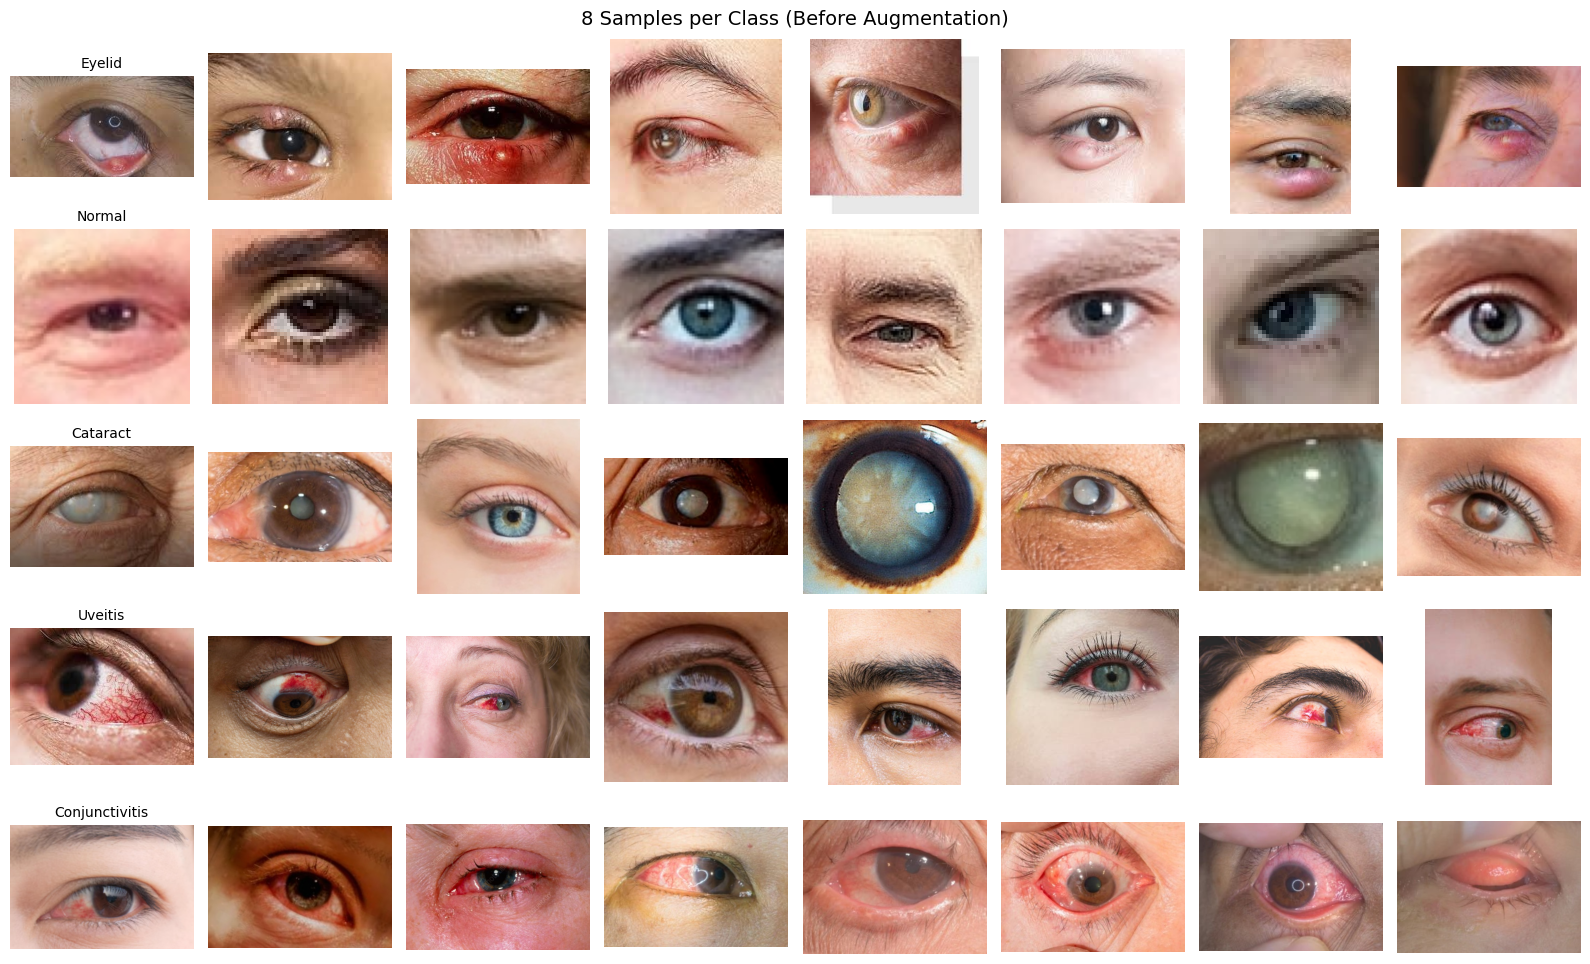

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
classes = os.listdir(dataset_path)

fig, axes = plt.subplots(len(classes), 8, figsize=(16, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    sampled_images = random.sample(images, 8)

    for j, img_name in enumerate(sampled_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        # فقط روی اولین ستون label بنویس
        if j == 0:
            axes[i, j].set_title(cls, fontsize=10)

plt.suptitle("8 Samples per Class (Before Augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

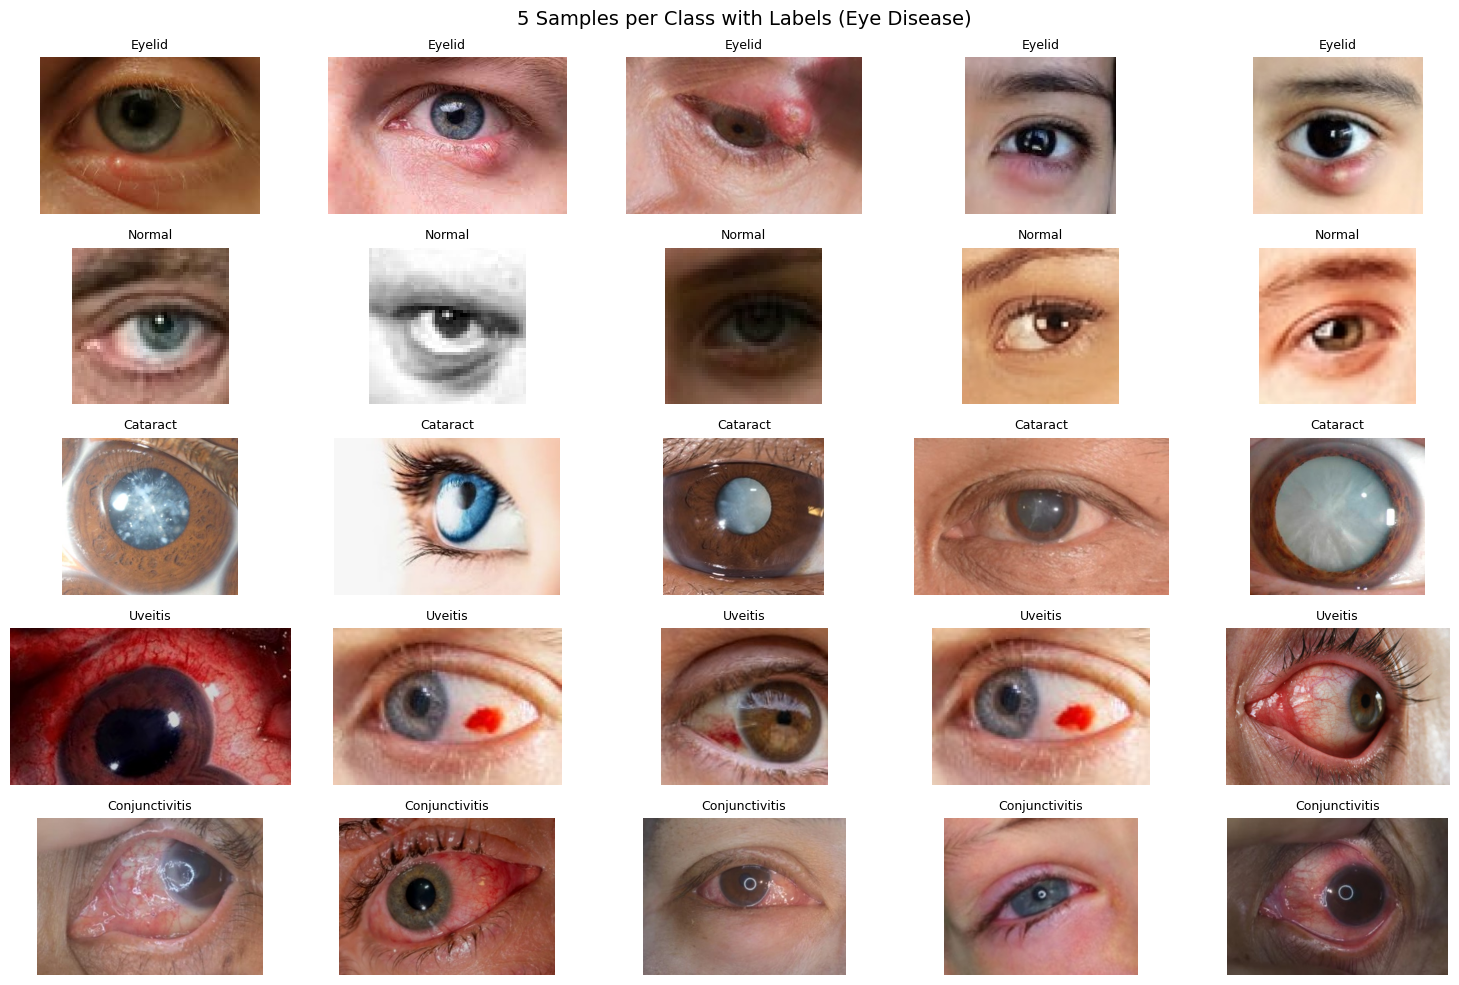

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
classes = os.listdir(dataset_path)

fig, axes = plt.subplots(len(classes), 5, figsize=(15, 10))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    sampled_images = random.sample(images, 5)

    for j, img_name in enumerate(sampled_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).convert("RGB")

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        # ✔ برچسب روی هر تصویر
        axes[i, j].set_title(cls, fontsize=9)

plt.suptitle("5 Samples per Class with Labels (Eye Disease)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Classes:", dataset.classes)
print("Total images:", len(dataset))

Classes: ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
Total images: 2298


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
dataset = datasets.ImageFolder(dataset_path)

class_counts = [0] * len(dataset.classes)

for _, label in dataset.samples:
    class_counts[label] += 1

print("Class counts:", dict(zip(dataset.classes, class_counts)))

Class counts: {'Cataract': 544, 'Conjunctivitis': 357, 'Eyelid': 525, 'Normal': 649, 'Uveitis': 223}


In [ ]:
from torchvision import datasets

dataset = datasets.ImageFolder(dataset_path)
print(dataset.classes)
print(len(dataset))

['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
2298


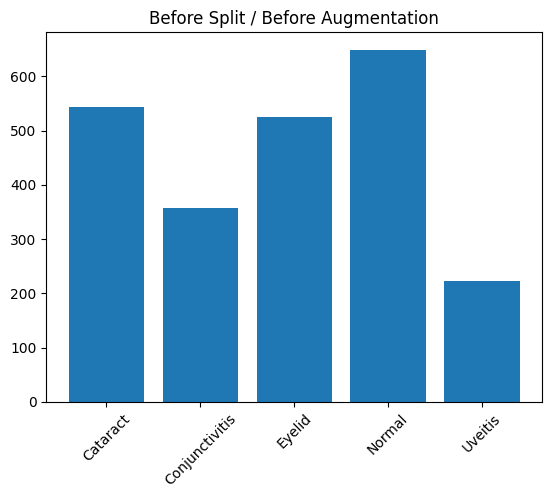

In [ ]:
import os
import matplotlib.pyplot as plt

class_counts = {}

for c in dataset.classes:
    class_dir = os.path.join(dataset_path, c)
    class_counts[c] = len(os.listdir(class_dir))

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Before Split / Before Augmentation")
plt.xticks(rotation=45)
plt.show()

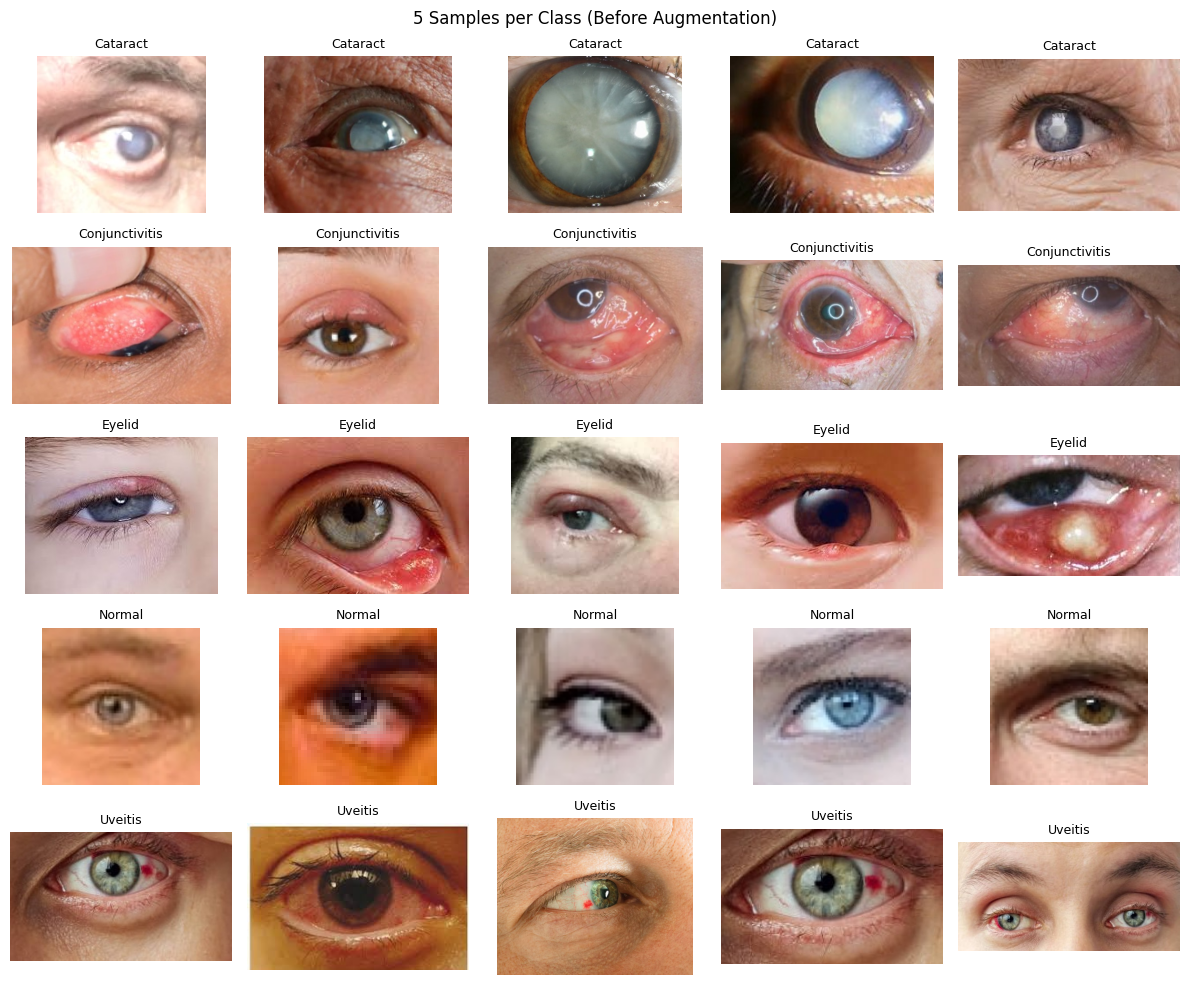

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(dataset.classes), 5, figsize=(12,10))

for i, cls in enumerate(dataset.classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)

    samples = random.sample(images, 5)

    for j, img_name in enumerate(samples):
        img = Image.open(os.path.join(class_path, img_name)).convert("RGB")

        axes[i,j].imshow(img)
        axes[i,j].axis("off")
        axes[i,j].set_title(cls, fontsize=9)

plt.suptitle("5 Samples per Class (Before Augmentation)")
plt.tight_layout()
plt.show()


Image count per class:
Cataract: 544
Conjunctivitis: 357
Eyelid: 525
Normal: 649
Uveitis: 223


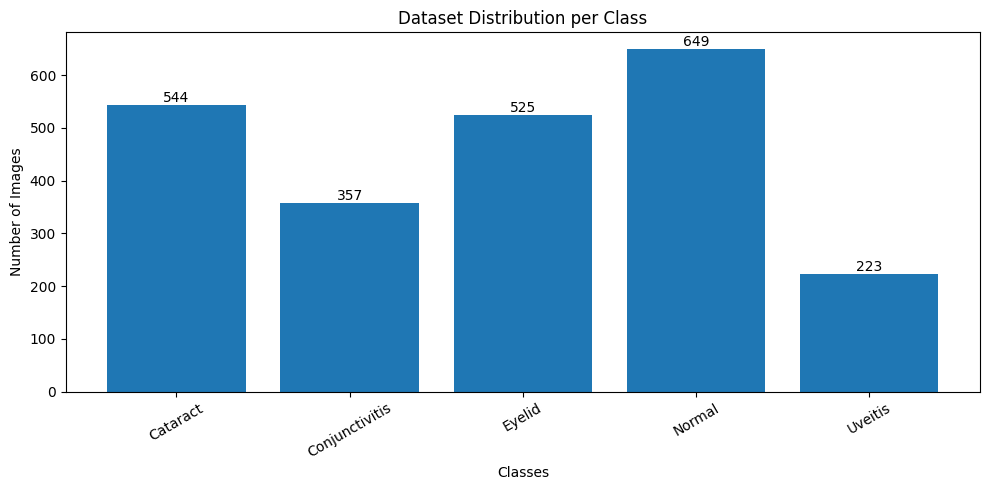

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Path to your dataset
dataset_path = path + "/Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"

image_ext = ('.jpg', '.jpeg', '.png')

# Get classes automatically
classes = sorted([
    c for c in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, c))
])

def count_images(class_name):
    folder_path = os.path.join(dataset_path, class_name)
    if not os.path.exists(folder_path):
        return 0

    return len([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(image_ext)
    ])

# Build count vector (single row since no train/val/test split)
counts = np.array([count_images(c) for c in classes])

print("\nImage count per class:")
for c, n in zip(classes, counts):
    print(f"{c}: {n}")

# Plot bar chart
plt.figure(figsize=(10,5))
plt.bar(classes, counts)

plt.title("Dataset Distribution per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

# Add numbers on bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd

# Correct path from the kagglehub download
base_path = path # Corrected: Use the global 'path' variable from kagglehub download
inner_folder = "Image Dataset on Eye Diseases Classification (Uveitis, Conjunctivitis, Cataract, Eyelid) with Symptoms and SMOTE Validation"
dataset_path = os.path.join(base_path, inner_folder)

image_ext = ('.jpg', '.jpeg', '.png')

def prepare_dataset_splits(dataset_path, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
    assert abs((train_size + val_size + test_size) - 1.0) < 1e-9
    classes = sorted([c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))])
    all_filepaths = []
    all_labels = []
    for class_idx, class_name in enumerate(classes):
        folder_path = os.path.join(dataset_path, class_name)
        files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.lower().endswith(image_ext)]
        all_filepaths.extend(files)
        all_labels.extend([class_idx] * len(files))

    all_filepaths = np.array(all_filepaths)
    all_labels = np.array(all_labels)
    X_train, X_temp, y_train, y_temp = train_test_split(all_filepaths, all_labels, train_size=train_size, stratify=all_labels, random_state=random_state)
    rel_val = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=rel_val, stratify=y_temp, random_state=random_state)

    pd.DataFrame({'filepath': X_train, 'label': y_train}).to_csv('train_split.csv', index=False)
    pd.DataFrame({'filepath': X_val, 'label': y_val}).to_csv('val_split.csv', index=False)
    pd.DataFrame({'filepath': X_test, 'label': y_test}).to_csv('test_split.csv', index=False)

    weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    print(f"Created CSVs for {len(all_labels)} images. Classes: {classes}")
    return weights, classes

if os.path.exists(dataset_path):
    weights, class_names = prepare_dataset_splits(dataset_path)
else:
    print(f"Still cannot find: {dataset_path}")

Created CSVs for 2298 images. Classes: ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

class EyeDiseaseDataset(Dataset):
    """Custom Dataset for reading paths and labels from our generated CSVs."""

    def __init__(self, csv_file, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with filepaths and labels.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.data_frame = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        # Read the filepath from the first column of the CSV
        img_name = self.data_frame.iloc[idx, 0]

        # Open image and convert to RGB (handles grayscale or RGBA images safely)
        image = Image.open(img_name).convert('RGB')

        # Read the label from the second column
        label = int(self.data_frame.iloc[idx, 1])

        # Apply augmentations/transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label


def get_dataloaders(batch_size=32, img_size=224):
    """
    Sets up the DataLoaders with specific augmentations for training
    and standard transforms for validation/testing.
    """

    # 1. Data Augmentation for Training
    # This helps the model generalize, especially for minority classes like Uveitis
    train_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),          # Randomly flip images horizontally
        transforms.RandomRotation(degrees=15),           # Randomly rotate by up to 15 degrees
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Slight color/lighting changes
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], # Standard ImageNet normalization means
                             std=[0.229, 0.224, 0.225])  # Standard ImageNet normalization stds
    ])

    # 2. Basic transforms for Validation and Testing
    # We NEVER augment validation or test data!
    val_test_transforms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # 3. Instantiate the Custom Datasets
    train_dataset = EyeDiseaseDataset(csv_file='train_split.csv', transform=train_transforms)
    val_dataset = EyeDiseaseDataset(csv_file='val_split.csv', transform=val_test_transforms)
    test_dataset = EyeDiseaseDataset(csv_file='test_split.csv', transform=val_test_transforms)

    # 4. Instantiate the DataLoaders
    # num_workers speeds up data loading, pin_memory speeds up CPU to GPU transfer
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


if __name__ == "__main__":
    # Test the DataLoaders
    print("Initializing DataLoaders...")
    train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)

    print(f"Number of training batches: {len(train_loader)}")
    print(f"Number of validation batches: {len(val_loader)}")

    # Fetch a single batch to verify shapes
    images, labels = next(iter(train_loader))
    print(f"\nBatch image shape: {images.shape}") # Should be [32, 3, 224, 224]
    print(f"Batch label shape: {labels.shape}")   # Should be [32]

    # The weights you generated in the previous step go directly into your loss function!
    # Example snippet for when you build your training loop:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    class_weights = torch.tensor([0.8441, 1.2864, 0.8763, 0.7084, 2.0615], dtype=torch.float32).to(device)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

    print("\nDataset pipeline is fully ready for model training!")

Initializing DataLoaders...
Number of training batches: 51
Number of validation batches: 11

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])

Dataset pipeline is fully ready for model training!



Count matrix (rows=train, val, test):
[[381 250 367 454 156]
 [ 81  54  79  97  34]
 [ 82  53  79  98  33]]


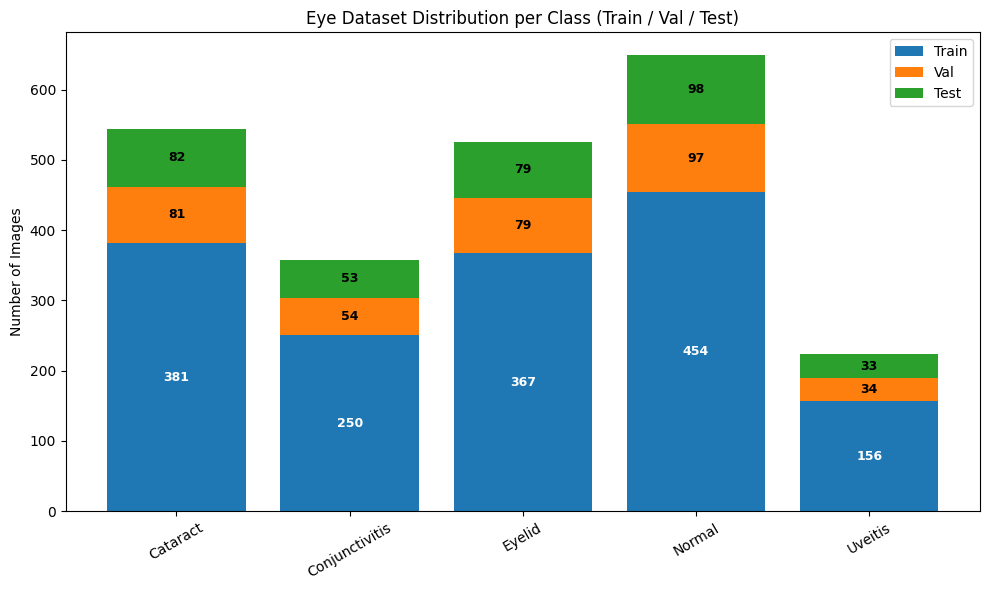

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# METHODOLOGY JUSTIFICATION FOR PAPER (Handling Class Imbalance)
# ==============================================================================
# 1. Stratified Splitting: The dataset was split using stratification to ensure
#    the original class distribution is strictly preserved across Train, Validation,
#    and Test sets. This prevents evaluation bias.
# 2. Class Weighting: Class weights were calculated (higher weights for minority
#    classes like Uveitis) and applied to the loss function (e.g., CrossEntropyLoss)
#    to prevent the model from ignoring underrepresented classes.
# 3. Safe Data Augmentation: Augmentation techniques (rotation, flipping, etc.)
#    were applied ONLY to the training set to prevent overfitting and enrich
#    minority classes, ensuring zero data leakage to validation/test sets.
# 4. Robust Evaluation Metrics: Due to the mild-to-moderate imbalance, evaluation
#    relies on metrics like F1-Score, Balanced Accuracy, and AUC, rather than
#    relying solely on standard Accuracy.
# ==============================================================================

# The classes are indexed alphabetically based on our previous setup
classes = ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
splits = ['train', 'val', 'test']

# Set this to the directory where your CSV files are saved.
# In Kaggle, you might need to change this to '/kaggle/working/'
csv_dir = './'

def get_counts_from_csv():
    counts = []
    for split in splits:
        csv_file = f"{split}_split.csv"
        csv_path = os.path.join(csv_dir, csv_file)

        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            # Count occurrences of each label (0 to 4)
            split_counts = [len(df[df['label'] == i]) for i in range(len(classes))]
            counts.append(split_counts)
        else:
            print(f"Warning: {csv_path} not found. Filling with zeros.")
            counts.append([0] * len(classes))
    return np.array(counts)

# Build count matrix (shape = 3, num_classes)
counts = get_counts_from_csv()

print("\nCount matrix (rows=train, val, test):")
print(counts)

# Plot the chart
x = np.arange(len(classes))
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(classes))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue for train, Orange for val, Green for test

for i, split in enumerate(splits):
    ax.bar(x, counts[i], bottom=bottom, label=split.capitalize(), color=colors[i])
    bottom += counts[i]

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30)
ax.set_ylabel("Number of Images")
ax.set_title("Eye Dataset Distribution per Class (Train / Val / Test)")
ax.legend()

# Add numeric labels on the bars
bottom = np.zeros(len(classes))
for i in range(len(splits)):
    for j in range(len(classes)):
        height = counts[i][j]
        if height > 0:
            ax.text(
                j,
                bottom[j] + height / 2,
                str(height),
                ha='center',
                va='center',
                fontsize=9,
                color='white' if i == 0 else 'black', # Make text visible based on bar color
                fontweight='bold'
            )
    bottom += counts[i]

plt.tight_layout()
plt.show()


Count matrix (rows=train, val, test):
[[381 250 367 454 156]
 [ 81  54  79  97  34]
 [ 82  53  79  98  33]]


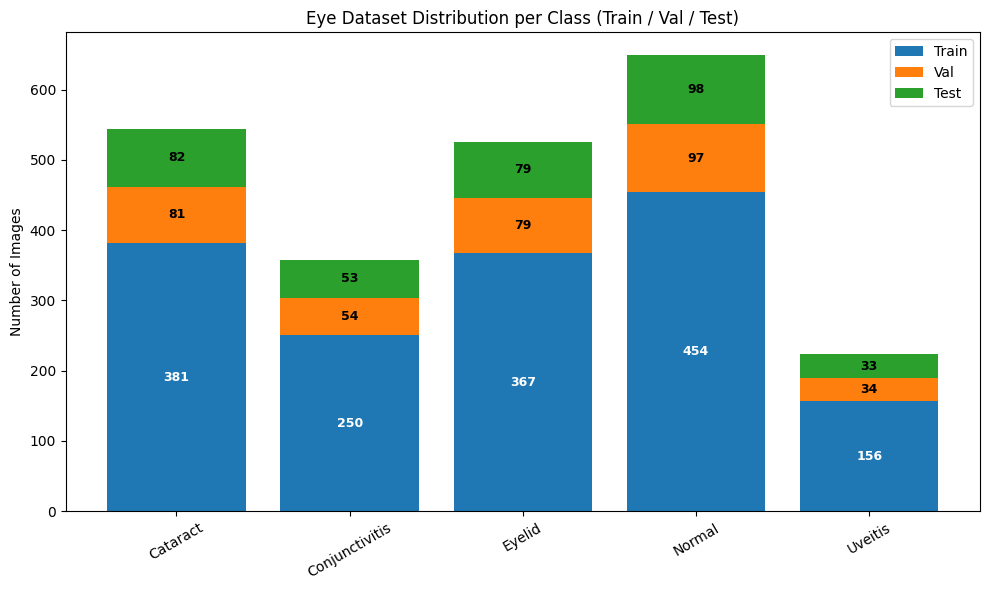

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# METHODOLOGY JUSTIFICATION FOR PAPER (Handling Class Imbalance)
# ==============================================================================
# 1. Stratified Splitting: The dataset was split using stratification to ensure
#    the original class distribution is strictly preserved across Train, Validation,
#    and Test sets. This prevents evaluation bias.
# 2. Class Weighting: Class weights were calculated (higher weights for minority
#    classes like Uveitis) and applied to the loss function (e.g., CrossEntropyLoss)
#    to prevent the model from ignoring underrepresented classes.
# 3. Safe Data Augmentation: Augmentation techniques (rotation, flipping, etc.)
#    were applied ONLY to the training set to prevent overfitting and enrich
#    minority classes, ensuring zero data leakage to validation/test sets.
# 4. Robust Evaluation Metrics: Due to the mild-to-moderate imbalance, evaluation
#    relies on metrics like F1-Score, Balanced Accuracy, and AUC, rather than
#    relying solely on standard Accuracy.
# ==============================================================================

# The classes are indexed alphabetically based on our previous setup
classes = ['Cataract', 'Conjunctivitis', 'Eyelid', 'Normal', 'Uveitis']
splits = ['train', 'val', 'test']

def get_counts_from_csv():
    counts = []
    for split in splits:
        csv_file = f"{split}_split.csv"
        if os.path.exists(csv_file):
            df = pd.read_csv(csv_file)
            # Count occurrences of each label (0 to 4)
            split_counts = [len(df[df['label'] == i]) for i in range(len(classes))]
            counts.append(split_counts)
        else:
            print(f"Warning: {csv_file} not found. Filling with zeros.")
            counts.append([0] * len(classes))
    return np.array(counts)

# Build count matrix (shape = 3, num_classes)
counts = get_counts_from_csv()

print("\nCount matrix (rows=train, val, test):")
print(counts)

# Plot the chart
x = np.arange(len(classes))
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(classes))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue for train, Orange for val, Green for test

for i, split in enumerate(splits):
    ax.bar(x, counts[i], bottom=bottom, label=split.capitalize(), color=colors[i])
    bottom += counts[i]

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30)
ax.set_ylabel("Number of Images")
ax.set_title("Eye Dataset Distribution per Class (Train / Val / Test)")
ax.legend()

# Add numeric labels on the bars
bottom = np.zeros(len(classes))
for i in range(len(splits)):
    for j in range(len(classes)):
        height = counts[i][j]
        if height > 0:
            ax.text(
                j,
                bottom[j] + height / 2,
                str(height),
                ha='center',
                va='center',
                fontsize=9,
                color='white' if i == 0 else 'black', # Make text visible based on bar color
                fontweight='bold'
            )
    bottom += counts[i]

plt.tight_layout()
plt.show()

In [ ]:
!pip install thop

In [ ]:
# =========================================================================
# KAGGLE / COLAB SETUP & ADVANCED PIPELINE
# =========================================================================
# 1. Install required packages:
# !pip install timm albumentations thop opencv-python-headless kagglehub
# =========================================================================

import os, random, time, gc, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from PIL import Image
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, cohen_kappa_score,
                             matthews_corrcoef, log_loss, roc_curve,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score, brier_score_loss)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.manifold import TSNE
from scipy.stats import wilcoxon, kruskal
from scipy.optimize import minimize  # <-- ADDED FOR SLSQP OPTIMIZATION
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm import tqdm
import platform, warnings
import kagglehub

# Optional imports
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
    print("Warning: 'cv2' not found. Grad-CAM for ViT will use PIL for resizing.")

try:
    from thop import profile
    THOP_AVAILABLE = True
except ImportError:
    THOP_AVAILABLE = False
    print("Warning: 'thop' not found. FLOPs will be estimated.")

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

# =========================================================================
# Clinical limitations and reproducibility
# =========================================================================
def print_clinical_limitations():
    print("\n" + "="*75)
    print("=== CLINICAL LIMITATIONS & DESIGN JUSTIFICATIONS ===")
    print("1. OVERFITTING MITIGATION: Label Smoothing (0.1), MixUp Regularization,")
    print("   Bootstrapping, and safe data augmentations used to prevent overconfidence.")
    print("2. EXTERNAL VALIDATION: Domain shift is simulated via stress testing")
    print("   to assess Out-of-Distribution (OOD) robustness.")
    print("3. PIPELINE ADAPTATION: LR Warm-up and SLSQP Ensemble Optimization active.")
    print("="*75 + "\n")

def log_hardware_and_reproducibility():
    print("\n" + "="*50)
    print("=== Hardware, Reproducibility & Clinical Setup ===")
    print(f"OS: {platform.system()} | PyTorch: {torch.__version__}")
    if torch.cuda.is_available():
        print(f"GPU count: {torch.cuda.device_count()}")
        for i in range(torch.cuda.device_count()):
            print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    print("Seed: 42 | Bootstrapping: 1000 iterations | 95% CI: Enabled")
    print("="*50 + "\n")

log_hardware_and_reproducibility()
print_clinical_limitations()

# ------------------------------------------------------------------
# 1. Configuration and globals
# ------------------------------------------------------------------
SEED = 42
EPOCHS = 30
PATIENCE = 3
BATCH = 64
LR = 5e-4
WARMUP_EPOCHS = 3  # Crucial for ViT/ConvNeXt stability
MIXUP_ALPHA = 0.2  # MixUp hyperparameter

# Fixed IMG_SIZE to 224 to match standard ViT input requirements
IMG_SIZE = 224

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

# Globals to be dynamically updated
CLASSES = []
N_CLASSES = 0

MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
TTA_STEPS = 5
LABEL_SMOOTHING = 0.1

SAVE_DIR = './results'
LATEX_DIR = os.path.join(SAVE_DIR, 'latex_tables')
RESULTS_DIR = SAVE_DIR
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(LATEX_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------------
# 2. Data Preparation (KaggleHub Integration)
# ------------------------------------------------------------------
def prepare_data():
    """
    Downloads the Eye Diseases dataset and splits it into Train/Val/Test.
    Returns: tr_list, va_list, te_list
    """
    global CLASSES, N_CLASSES
    print("Downloading/Loading dataset via kagglehub...")
    path = kagglehub.dataset_download('gunavenkatdoddi/eye-diseases-classification')
    print(f"Dataset downloaded to: {path}")

    data_root = os.path.join(path, 'dataset')
    if not os.path.exists(data_root):
        data_root = path

    # Fetch raw class names from folder directories (sorted alphabetically)
    raw_classes = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])

    # Explicitly map the requested specific class names
    CLASSES = ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']
    N_CLASSES = len(CLASSES)

    print(f"Detected Classes: {CLASSES} (Total: {N_CLASSES})")

    all_image_paths, all_labels = [], []
    for idx, cls_name_raw in enumerate(raw_classes):
        cls_folder = os.path.join(data_root, cls_name_raw)
        images = glob.glob(os.path.join(cls_folder, "*"))
        images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        for img_path in images:
            all_image_paths.append(img_path)
            all_labels.append(idx)

    # 70% Train, 15% Val, 15% Test
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_image_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
    )

    tr_list = list(zip(X_train, y_train))
    va_list = list(zip(X_val, y_val))
    te_list = list(zip(X_test, y_test))

    return tr_list, va_list, te_list

# ------------------------------------------------------------------
# 3. Transforms and Dataset
# ------------------------------------------------------------------
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.7),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1, p=0.5),
    A.CoarseDropout(p=0.5),
    A.CLAHE(p=0.3),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.Normalize(MEAN, STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(MEAN, STD),
    ToTensorV2()
])

tta_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.Normalize(MEAN, STD),
    ToTensorV2(),
])

domain_shifts = {
    'Baseline (No Perturbation)': val_transform,
    'Brightness (+20%)': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.ColorJitter(brightness=(0.2, 0.2), contrast=0, saturation=0, hue=0, p=1.0),
        A.Normalize(MEAN, STD),
        ToTensorV2()
    ]),
    'Contrast (+20%)': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.ColorJitter(brightness=0, contrast=(0.2, 0.2), saturation=0, hue=0, p=1.0),
        A.Normalize(MEAN, STD),
        ToTensorV2()
    ]),
    r'Gaussian Noise (\sigma=0.05)': A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.GaussNoise(p=1.0),
        A.Normalize(MEAN, STD),
        ToTensorV2()
    ]),
    'Resolution Reduction': A.Compose([
        A.Resize(IMG_SIZE // 2, IMG_SIZE // 2),
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(MEAN, STD),
        ToTensorV2()
    ])
}

class MedicalDataset(Dataset):
    """Custom Dataset for eye disease images with error handling."""
    def __init__(self, samples, transform=None, is_tta=False):
        self.samples = samples
        self.transform = transform
        self.is_tta = is_tta

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = np.array(Image.open(path).convert('RGB'))
        except Exception as e:
            # Fallback to prevent crashing on bad images
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)

        if self.is_tta:
            images = [self.transform(image=img)['image'] for _ in range(TTA_STEPS)]
            return torch.stack(images), F.one_hot(torch.tensor(label), N_CLASSES).float()

        if self.transform:
            img = self.transform(image=img)['image']
        return img, F.one_hot(torch.tensor(label), N_CLASSES).float()

# ------------------------------------------------------------------
# 4. Model Architecture (CNN + ViT compatible)
# ------------------------------------------------------------------
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block."""
    def __init__(self, c, r=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        bs, c, _, _ = x.shape
        y = self.squeeze(x).view(bs, c)
        y = self.excitation(y).view(bs, c, 1, 1)
        return x * y.expand_as(x)

class LearnableAdjacency(nn.Module):
    """Learnable adjacency matrix for GCN."""
    def __init__(self, n_classes, init_adj=None):
        super().__init__()
        if init_adj is None:
            init_adj = torch.eye(n_classes) + 0.1
        self.adj = nn.Parameter(init_adj.clone(), requires_grad=True)

    def forward(self):
        adj = F.relu(self.adj)
        adj = (adj + adj.t()) / 2                  # symmetry
        adj = adj / (adj.sum(1).unsqueeze(1) + 1e-9)  # normalise
        return adj

class CustomModel(nn.Module):
    """
    Generic model supporting CNN backbones (with SE block) and Vision Transformers.
    Uses multi-task heads and optional Graph Convolutional Network (GCN).
    """
    def __init__(self, model_name='densenet121', pretrained=True, adj=None,
                 use_se=True, use_gcn=True, use_multi_task=True, learnable_adj=False):
        super().__init__()
        self.model_name = model_name
        self.model = timm.create_model(model_name, pretrained=pretrained,
                                       num_classes=0, global_pool='')
        # Detect backbone type
        with torch.no_grad():
            out = self.model(torch.randn(2, 3, IMG_SIZE, IMG_SIZE))
        self.is_vit = (out.dim() == 3)   # CNN: [B,C,H,W], ViT: [B,N,D]

        if not self.is_vit:
            self.n_features = out.shape[1]   # number of channels
        else:
            self.n_features = out.shape[-1]  # embedding dimension

        # SE block only for CNNs
        self.use_se = use_se and not self.is_vit
        self.attention = SEBlock(self.n_features) if self.use_se else nn.Identity()

        # Pooling / token averaging
        if self.is_vit:
            self.pool = lambda x: x.mean(dim=1)   # average over tokens
        else:
            self.pool = nn.AdaptiveAvgPool2d(1)

        # Multi-task heads (one binary head per class)
        self.use_multi_task = use_multi_task
        if use_multi_task:
            self.heads = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(self.n_features, 512),
                    nn.BatchNorm1d(512),
                    nn.ReLU(inplace=True),
                    nn.Dropout(0.6),
                    nn.Linear(512, 1)
                ) for _ in range(N_CLASSES)
            ])
        else:
            self.classifier = nn.Sequential(
                nn.Linear(self.n_features, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(inplace=True),
                nn.Dropout(0.6),
                nn.Linear(512, N_CLASSES)
            )

        # GCN branch
        self.use_gcn = use_gcn
        self.learnable_adj = learnable_adj
        if use_gcn:
            if learnable_adj:
                self.adj = LearnableAdjacency(N_CLASSES, init_adj=adj)
            else:
                self.adj = adj if adj is not None else torch.eye(N_CLASSES)

    def forward(self, x):
        features = self.model(x)   # CNN: (B,C,H,W), ViT: (B,N,D)
        if not self.is_vit:
            features = self.attention(features)
            pooled = self.pool(features)          # (B,C,1,1)
            flattened = torch.flatten(pooled, 1)   # (B,C)
        else:
            features = self.attention(features)   # Identity
            flattened = self.pool(features)       # (B,D)

        logits = torch.cat([head(flattened) for head in self.heads], dim=1) \
                 if self.use_multi_task else self.classifier(flattened)

        if self.use_gcn:
            adj_matrix = self.adj() if self.learnable_adj else self.adj.to(logits.device)
            logits = logits + F.relu(torch.matmul(adj_matrix, logits.t())).t()
        return logits

    def extract_features(self, x):
        """Extract latent features for t-SNE."""
        with torch.no_grad():
            features = self.model(x)
            if not self.is_vit:
                features = self.attention(features)
                pooled = self.pool(features)
                return torch.flatten(pooled, 1)
            else:
                return self.pool(features)

# ------------------------------------------------------------------
# Grad-CAM (CNN + ViT)
# ------------------------------------------------------------------
class GradCAM_CNN:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []

        def forward_hook(module, inp, out):
            self.activations = out.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hook_handles.append(target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(target_layer.register_full_backward_hook(backward_hook))

    def generate(self, input_tensor, target_class):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(input_tensor)
        score = logits[0, target_class]
        score.backward(retain_graph=True)

        if self.gradients is None or self.activations is None:
            return None

        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze(0)
        cam = F.relu(cam)

        cam_min, cam_max = torch.min(cam), torch.max(cam)
        if cam_max == cam_min:
            return np.zeros_like(cam.cpu().numpy())
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam.cpu().numpy()

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

class GradCAM_ViT:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.attentions = None
        self.hook_handle = target_layer.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.attentions = out.detach()

    def generate(self, input_tensor, target_class):
        self.model.eval()
        self.model.zero_grad()
        logits = self.model(input_tensor)
        score = logits[0, target_class]
        score.backward(retain_graph=True)

        if self.attentions is None:
            return None

        attn_map = self.attentions.mean(dim=1)[0]
        if attn_map.shape[0] == attn_map.shape[1] + 1:
            cam = attn_map[0, 1:]
        else:
            cam = attn_map.mean(dim=0)

        num_patches = cam.shape[0]
        w = h = int(np.sqrt(num_patches))
        if w * h != num_patches:
            cam = cam.reshape(1, 1, num_patches).unsqueeze(0)
            cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE),
                                mode='bilinear', align_corners=False).squeeze().numpy()
        else:
            cam = cam.reshape(w, h).cpu().numpy()
            if CV2_AVAILABLE:
                cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
            else:
                cam = np.array(Image.fromarray(cam).resize((IMG_SIZE, IMG_SIZE)))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove_hooks(self):
        self.hook_handle.remove()

def get_target_layer(model_instance, model_name):
    backbone = model_instance.model
    name_lower = model_name.lower()

    if 'densenet' in name_lower:
        return backbone.features.denseblock4.denselayer16.conv2
    elif 'efficientnet' in name_lower or 'tf_efficientnet' in name_lower:
        return backbone.conv_head
    elif 'resnet' in name_lower or 'resnext' in name_lower:
        return backbone.layer4[-1]
    elif 'convnext' in name_lower:
        return backbone.stages[-1][-1].conv_dw
    elif 'vit' in name_lower or 'deit' in name_lower:
        try: return backbone.blocks[-1].attn.attn_drop
        except: pass
    elif 'swin' in name_lower:
        try: return backbone.layers[-1].blocks[-1].attn.attn_drop
        except: pass
    elif 'beit' in name_lower:
        try: return backbone.blocks[-1].attn.attn_drop
        except: pass

    try:
        for module in reversed(list(backbone.modules())):
            if isinstance(module, nn.Conv2d):
                return module
    except Exception:
        pass
    return None

def generate_gradcam_visualizations(te_list, y_true, y_preds, y_probs,
                                    models_dict, misclassified=True, n=10,
                                    save_name="gradcam.png"):
    print(f"\n=== Generating Grad-CAM ({save_name}) ===")
    random.seed(SEED + 6)
    np.random.seed(SEED + 6)
    torch.manual_seed(SEED + 6)

    if misclassified:
        indices = np.where(y_true != y_preds)[0]
        main_title = "Grad-CAM on Misclassified Samples (Weighted Ensemble)"
    else:
        indices = np.where(y_true == y_preds)[0]
        main_title = "Grad-CAM on Correctly Classified Samples (Weighted Ensemble)"

    np.random.shuffle(indices)
    indices = indices[:min(n, len(indices))]
    if len(indices) == 0:
        print("  No samples found for Grad-CAM.")
        return

    spatial_models = list(models_dict.keys())
    if not spatial_models:
        print("  No spatial models available.")
        return

    num_cols = 5
    num_rows = (len(indices) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3.5 * num_rows))
    if len(indices) == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for r, idx in enumerate(indices):
        img_path, _ = te_list[idx]
        orig_img_pil = Image.open(img_path).convert('RGB')
        orig_w, orig_h = orig_img_pil.size
        orig_img_np = np.array(orig_img_pil)

        y_t = CLASSES[y_true[idx]]
        y_p = CLASSES[y_preds[idx]]
        conf = y_probs[idx, y_preds[idx]]

        cams = []
        for name in spatial_models:
            model = models_dict[name]
            transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE),
                                   A.Normalize(mean=MEAN, std=STD),
                                   ToTensorV2()])
            tensor = transform(image=orig_img_np)['image'].unsqueeze(0).to(DEVICE)

            target_layer = get_target_layer(model, name)
            if target_layer is None: continue

            if model.is_vit: gcam = GradCAM_ViT(model, target_layer)
            else: gcam = GradCAM_CNN(model, target_layer)

            with torch.set_grad_enabled(True):
                cam = gcam.generate(tensor, y_preds[idx])
            gcam.remove_hooks()

            if cam is not None and len(cam.shape) == 2:
                cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
                cam_resized = F.interpolate(cam_tensor, size=(orig_h, orig_w),
                                            mode='bilinear',
                                            align_corners=False).squeeze().numpy()
                cams.append(cam_resized)

        ax = axes[r]
        if cams:
            ens_cam = np.mean(cams, axis=0)
            heatmap = plt.cm.jet(ens_cam)[..., :3] * 255.0
            overlay = (heatmap * 0.4 + orig_img_np * 0.6).astype(np.uint8)
            ax.imshow(overlay)
        else:
            ax.imshow(orig_img_np)

        ax.set_title(f"True:{y_t}\nPred:{y_p} ({conf:.2f})", fontsize=10, color='black')
        ax.axis('off')

    for j in range(len(indices), len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle(main_title, fontsize=16, color='black', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, save_name), bbox_inches='tight', dpi=300)
    plt.close()

# ------------------------------------------------------------------
# 4. Loss function and utility metrics
# ------------------------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, weight=None, alpha=1.0, gamma=2, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.smoothing > 0:
            targets = targets * (1 - self.smoothing) + self.smoothing / N_CLASSES
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        f_loss = self.alpha * (1 - torch.exp(-bce_loss)) ** self.gamma * bce_loss
        if self.weight is not None:
            f_loss = f_loss * self.weight.to(logits.device)
        return f_loss.mean()

def compute_macro_specificity(cm):
    specs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
    return np.mean(specs)

def bootstrap_metrics(y_true, y_pred, y_prob, n_iterations=1000, alpha=0.95, return_dict=True):
    metrics = {'Accuracy': [], 'Balanced Acc': [], 'Precision': [], 'Recall': [],
               'F1-Score': [], 'Specificity': [], "Cohen's Kappa": [], 'MCC': [],
               'Log Loss': [], 'Brier Score': [], 'AUC': []}
    n_size = len(y_true)

    for _ in range(n_iterations):
        idx = resample(np.arange(n_size))
        yt, yp, yprob = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue

        metrics['Accuracy'].append(accuracy_score(yt, yp))
        metrics['Balanced Acc'].append(balanced_accuracy_score(yt, yp))
        metrics['Precision'].append(precision_score(yt, yp, average='weighted', zero_division=0))
        metrics['Recall'].append(recall_score(yt, yp, average='weighted', zero_division=0))
        metrics['F1-Score'].append(f1_score(yt, yp, average='weighted', zero_division=0))

        cm = confusion_matrix(yt, yp, labels=range(N_CLASSES))
        metrics['Specificity'].append(compute_macro_specificity(cm))
        metrics["Cohen's Kappa"].append(cohen_kappa_score(yt, yp))
        metrics['MCC'].append(matthews_corrcoef(yt, yp))

        try: metrics["Log Loss"].append(log_loss(yt, yprob, labels=range(N_CLASSES)))
        except: pass
        metrics['Brier Score'].append(np.mean([brier_score_loss((yt == i).astype(int), yprob[:, i]) for i in range(N_CLASSES)]))
        try:
            auc = roc_auc_score(yt, yprob, multi_class="ovo", average="macro") if N_CLASSES > 2 else roc_auc_score(yt, yprob[:, 1])
            metrics['AUC'].append(auc)
        except: pass

    res_str = {}
    res_val = {}
    lower_p, upper_p = ((1.0 - alpha) / 2.0) * 100, (alpha + ((1.0 - alpha) / 2.0)) * 100
    for k, v in metrics.items():
        if v:
            m, l, u = np.mean(v), np.percentile(v, lower_p), np.percentile(v, upper_p)
            res_val[k] = m
            if k in ["Log Loss", "Brier Score", "AUC", "Cohen's Kappa", "MCC"]:
                res_str[k] = f"{m:.4f} ({l:.4f}-{u:.4f})"
            else:
                res_str[k] = f"{m*100:.2f} ({l*100:.2f}-{u*100:.2f})"
        else:
            res_str[k] = "N/A"
            res_val[k] = 0.0

    if return_dict: return res_val
    return res_str

def bootstrap_per_class_metrics(y_true, y_pred, y_prob, class_idx, n_iterations=1000, alpha=0.95, return_dict=True):
    metrics = {'Accuracy': [], 'Balanced Acc': [], 'Precision': [], 'Recall': [],
               'F1-Score': [], 'Specificity': [], "Cohen's Kappa": [], 'MCC': [],
               'Log Loss': [], 'Brier Score': [], 'AUC': [], 'FNR': [], 'Support': []}
    n_size = len(y_true)

    for _ in range(n_iterations):
        idx = resample(np.arange(n_size))
        yt_orig, yp_orig, yprob_orig = y_true[idx], y_pred[idx], y_prob[idx]

        yt = (yt_orig == class_idx).astype(int)
        yp = (yp_orig == class_idx).astype(int)
        yprob_cls = yprob_orig[:, class_idx]

        if len(np.unique(yt)) < 2: continue

        cm = confusion_matrix(yt, yp, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp + 1e-9)
        fnr = fn / (fn + tp + 1e-9)

        metrics['Accuracy'].append(accuracy_score(yt, yp))
        metrics['Balanced Acc'].append(balanced_accuracy_score(yt, yp))
        metrics['Precision'].append(precision_score(yt, yp, zero_division=0))
        metrics['Recall'].append(recall_score(yt, yp, zero_division=0))
        metrics['F1-Score'].append(f1_score(yt, yp, zero_division=0))
        metrics['Specificity'].append(specificity)
        metrics["Cohen's Kappa"].append(cohen_kappa_score(yt, yp))
        metrics['MCC'].append(matthews_corrcoef(yt, yp))
        try: metrics['Log Loss'].append(log_loss(yt, yprob_cls, labels=[0, 1]))
        except: pass
        metrics['Brier Score'].append(brier_score_loss(yt, yprob_cls))
        try: metrics['AUC'].append(roc_auc_score(yt, yprob_cls))
        except: pass
        metrics['FNR'].append(fnr)
        metrics['Support'].append(np.sum(yt))

    res_str, res_val = {}, {}
    lower_p, upper_p = ((1.0 - alpha) / 2.0) * 100, (alpha + ((1.0 - alpha) / 2.0)) * 100
    for k, v in metrics.items():
        if v and k != 'Support':
            m, l, u = np.mean(v), np.percentile(v, lower_p), np.percentile(v, upper_p)
            res_val[k] = m
            if k in ["Log Loss", "Brier Score", "AUC", "Cohen's Kappa", "MCC"]:
                res_str[k] = f"{m:.4f} ({l:.4f}-{u:.4f})"
            else:
                res_str[k] = f"{m*100:.2f} ({l*100:.2f}-{u*100:.2f})"
        elif k == 'Support':
            res_val[k] = np.mean(v)
            res_str[k] = str(int(np.mean(v)))
        else:
            res_val[k] = 0.0
            res_str[k] = "N/A"

    if return_dict: return res_val
    return res_str

def save_latex_to_file(content, filename):
    with open(os.path.join(LATEX_DIR, filename), 'w', encoding='utf-8') as f:
        f.write(content)

# ------------------------------------------------------------------
# 5. Training and evaluation loops
# ------------------------------------------------------------------
def validate_epoch(model, loader, criterion, device, desc="Validation"):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    t_labels, p_labels, p_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)

            prob = F.softmax(out, 1)
            pred = prob.argmax(1)
            correct += (pred == y.argmax(1)).sum().item()
            total += x.size(0)

            t_labels.append(y.cpu())
            p_labels.append(pred.cpu())
            p_probs.append(prob.cpu())

    return (loss_sum / total,
            correct / total,
            np.argmax(torch.cat(t_labels).numpy(), 1),
            torch.cat(p_labels).numpy(),
            torch.cat(p_probs).numpy())

@torch.no_grad()
def validate_tta(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    t_labels, p_labels, p_probs = [], [], []
    for x_tta, y in loader:
        y = y.to(device)
        bs, n_tta, c, h, w = x_tta.shape
        out = model(x_tta.view(-1, c, h, w).to(device))
        prob = F.softmax(out, 1).view(bs, n_tta, -1).mean(1)
        pred = prob.argmax(1)
        loss = criterion(torch.log(prob.clamp(min=1e-9)), y)
        loss_sum += loss.item() * bs
        correct += (pred == y.argmax(1)).sum().item()
        total += bs

        t_labels.append(y.cpu())
        p_labels.append(pred.cpu())
        p_probs.append(prob.cpu())

    return (loss_sum / total,
            correct / total,
            np.argmax(torch.cat(t_labels).numpy(), 1),
            torch.cat(p_labels).numpy(),
            torch.cat(p_probs).numpy())

def train_model(model, name, train_loader, val_loader, criterion, device, epochs=None):
    if epochs is None: epochs = EPOCHS
    if NUM_GPUS > 1: model = nn.DataParallel(model)
    model = model.to(device)

    # Note: For convergence analysis on specialized algorithms (e.g., Nova, Apollo, CosAdam),
    # you can seamlessly swap AdamW out and plug your custom optimizer class here.
    opt = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2) # Increased WD to 1e-2 for ViT/ConvNeXt stability

    # ------------------ LR WARM-UP ADDITION ------------------
    warmup_scheduler = LinearLR(opt, start_factor=0.01, total_iters=WARMUP_EPOCHS)
    cosine_scheduler = CosineAnnealingLR(opt, T_max=epochs - WARMUP_EPOCHS, eta_min=1e-6)
    sch = SequentialLR(opt, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS])
    # ---------------------------------------------------------

    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    best_v = float('inf')
    p_count = 0
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    start_time = time.time()

    try: autocast_ctx = torch.amp.autocast(device_type=device.type)
    except Exception:
        import contextlib
        autocast_ctx = contextlib.nullcontext()

    if name != "fold": print(f"\n--- Training {name} ---")

    for ep in range(1, epochs + 1):
        model.train()
        r_loss, r_corr, total = 0.0, 0, 0
        batch_pbar = tqdm(train_loader, desc=f"Ep {ep}/{epochs}", leave=False, unit="batch")
        for x, y in batch_pbar:
            x, y = x.to(device), y.to(device)

            # ------------------ MIXUP REGULARIZATION ------------------
            # Apply MixUp 50% of the time to improve manifold generalization
            if np.random.rand() < 0.5:
                lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
                rand_index = torch.randperm(x.size(0)).to(device)
                x = lam * x + (1 - lam) * x[rand_index, :]
                y = lam * y + (1 - lam) * y[rand_index, :]
            # ----------------------------------------------------------

            opt.zero_grad(set_to_none=True)
            with autocast_ctx:
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bs = x.size(0)
            r_loss += loss.item() * bs
            # Accuracy metric during training might be slightly offset by MixUp,
            # but validation accuracy handles the precise tracking.
            r_corr += (out.argmax(1) == y.argmax(1)).sum().item()
            total += bs
            batch_pbar.set_postfix(loss=f"{r_loss / total:.4f}")

        v_l, v_a, _, _, _ = validate_epoch(model, val_loader, criterion, device)
        tr_l = r_loss / total
        tr_a = r_corr / total

        hist['train_loss'].append(tr_l)
        hist['train_acc'].append(tr_a)
        hist['val_loss'].append(v_l)
        hist['val_acc'].append(v_a)
        sch.step()

        if name != "fold":
            log_str = f"🔹 [{name}] Ep {ep} -> Train Loss: {tr_l:.4f} | Acc: {tr_a:.4f} || Val Loss: {v_l:.4f} | Acc: {v_a:.4f}"
            if v_l < best_v:
                best_v = v_l
                p_count = 0
                model_to_save = model.module if hasattr(model, 'module') else model
                torch.save(model_to_save.state_dict(),
                           os.path.join(SAVE_DIR, f"best_model_{name}.pth"))
                log_str += "    ⭐ Best model saved!"
                print(log_str + "\n")
            else:
                p_count += 1
                if p_count >= PATIENCE:
                    log_str += f"    🛑 Early stopping at epoch {ep}"
                    print(log_str + "\n")
                    break
                else:
                    print(log_str + "\n")

    total_time = time.time() - start_time
    avg_runtime = total_time / len(hist['train_loss']) if hist['train_loss'] else 0
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return hist, avg_runtime

def ens_eval(probs_list, y_true, w):
    avg_p = np.average(np.array(probs_list), axis=0, weights=w)
    avg_p /= avg_p.sum(1, keepdims=True)
    preds = avg_p.argmax(1)
    return accuracy_score(y_true, preds), avg_p, preds

# ------------------------------------------------------------------
# 6. Visualization helpers
# ------------------------------------------------------------------
def plot_tsne(features, labels, title="t-SNE Plot"):
    tsne = TSNE(n_components=2, random_state=SEED)
    tsne_results = tsne.fit_transform(features)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1],
                    hue=[CLASSES[i] for i in labels],
                    palette=sns.color_palette("husl", N_CLASSES), legend="full", alpha=0.7)
    plt.title(title, fontsize=14)
    plt.savefig(os.path.join(RESULTS_DIR, f"{title.lower().replace(' ', '_')}.png"),
                dpi=300, bbox_inches='tight')
    plt.close()

def plot_roc(y_true, y_prob, title_prefix=""):
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    y_true_bin = label_binarize(y_true, classes=np.arange(N_CLASSES))
    colors = sns.color_palette("husl", N_CLASSES)
    for i in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f'{CLASSES[i]} (AUC={auc:.2f})', color=colors[i])
    macro_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovo", average="macro")
    plt.plot([0, 1], [0, 1], 'k--', label=f'Macro AUC={macro_auc:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title_prefix} ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(RESULTS_DIR, f'{title_prefix.lower().replace(" ", "_")}_roc.png'),
                dpi=300, bbox_inches='tight')
    plt.close()

def plot_prc(y_true, y_prob, title_prefix=""):
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    colors = sns.color_palette("husl", N_CLASSES)
    for i in range(N_CLASSES):
        precision, recall, _ = precision_recall_curve(y_true == i, y_prob[:, i])
        ap = average_precision_score(y_true == i, y_prob[:, i])
        plt.plot(recall, precision, label=f'{CLASSES[i]} (AP={ap:.2f})', color=colors[i])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(RESULTS_DIR, f'{title_prefix.lower().replace(" ", "_")}_prc.png'),
                dpi=300, bbox_inches='tight')
    plt.close()

def plot_cm(y_true, y_pred, model_name="", cmap='Blues'):
    cm = confusion_matrix(y_true, y_pred)
    misclass = cm.sum() - np.diag(cm).sum()
    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES,
                annot_kws={"size": 10}, cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix: {model_name}\n({misclass} misclassified)')
    plt.savefig(os.path.join(RESULTS_DIR, f'{model_name.lower().replace(" ", "_")}_cm.png'),
                dpi=300, bbox_inches='tight')
    plt.close()

def denormalize(img_tensor):
    mean = torch.tensor(MEAN).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor(STD).view(3, 1, 1).to(img_tensor.device)
    if img_tensor.dim() == 4:
        img_tensor = img_tensor.squeeze(0)
    img = img_tensor.cpu() * std.cpu() + mean.cpu()
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

def plot_misclassified_images(dataset, true_labels, predicted_labels, probabilities,
                              classes, num_cols=5, save_name="plot_misclassified.png"):
    idxs = np.where(true_labels != predicted_labels)[0]
    if len(idxs) == 0: return
    n_display = min(25, len(idxs))
    display_idxs = idxs[:n_display]
    rows = (len(display_idxs) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(rows, num_cols, figsize=(15, 3 * rows))
    if rows * num_cols == 1: axes = np.array([axes])
    axes = axes.flatten()
    for i, idx in enumerate(display_idxs):
        img_tensor, true_lbl_onehot = dataset[idx]
        true_lbl_idx = torch.argmax(true_lbl_onehot).item()
        ax = axes[i]
        ax.imshow(denormalize(img_tensor))
        ax.axis('off')
        pred_lbl_idx = predicted_labels[idx]
        confidence = probabilities[idx, pred_lbl_idx]
        ax.set_title(f"True: {classes[true_lbl_idx]}\nPred: {classes[pred_lbl_idx]} ({confidence:.2f})",
                     fontsize=9)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle("Misclassified Samples (Error Analysis)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

def plot_correctly_classified_images(dataset, true_labels, predicted_labels,
                                     probabilities, classes, n_display=20, num_cols=5,
                                     save_name="plot_correctly_classified.png"):
    idxs = np.where(true_labels == predicted_labels)[0]
    if len(idxs) == 0: return
    n_to_plot = min(n_display, len(idxs))
    sampled = random.sample(list(idxs), n_to_plot)
    rows = (len(sampled) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(rows, num_cols, figsize=(15, 3 * rows))
    if rows * num_cols == 1: axes = np.array([axes])
    axes = axes.flatten()
    for i, idx in enumerate(sampled):
        img_tensor, true_lbl_onehot = dataset[idx]
        true_lbl_idx = torch.argmax(true_lbl_onehot).item()
        ax = axes[i]
        ax.imshow(denormalize(img_tensor))
        ax.axis('off')
        confidence = probabilities[idx, true_lbl_idx]
        ax.set_title(f"{classes[true_lbl_idx]} ({confidence:.2f})", fontsize=9)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.suptitle("Correctly Classified Samples", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

@torch.no_grad()
def extract_features(model, loader, device):
    model.eval()
    all_features, all_labels = [], []
    for x, y in tqdm(loader, desc="Extracting Features", leave=False):
        x = x.to(device)
        feats = model.extract_features(x).cpu().numpy()
        all_features.append(feats)
        all_labels.append(y.argmax(1).cpu().numpy())
    if not all_features: return None, None
    return np.concatenate(all_features), np.concatenate(all_labels)

def plot_sample_images(dataset, title, n_per_class=5, num_cols=5, save_name="dataset_samples.png"):
    all_imgs = []
    for cls_idx in range(N_CLASSES):
        class_samples = [s for s in dataset.samples if s[1] == cls_idx]
        if len(class_samples) < n_per_class:
            all_imgs.extend(class_samples)
        else:
            all_imgs.extend(random.sample(class_samples, n_per_class))
    if not all_imgs: return
    all_imgs.sort(key=lambda x: x[1])
    total = len(all_imgs)
    rows = (total + num_cols - 1) // num_cols
    fig, axes = plt.subplots(rows, num_cols, figsize=(15, 3 * rows))
    if rows * num_cols == 1: axes = np.array([axes])
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.02)
    for i, (path, lbl) in enumerate(all_imgs):
        ax = axes[i]
        img = np.array(Image.open(path).convert('RGB'))
        ax.imshow(img)
        ax.set_title(f"Class: {CLASSES[lbl]}")
        ax.axis('off')
    for j in range(total, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.close()

# ------------------------------------------------------------------
# 7. Main execution: training, evaluation, tables
# ------------------------------------------------------------------
def main():
    # Load dynamically instead of CSV
    tr_list, va_list, te_list = prepare_data()
    print(f"Successfully split data: {len(tr_list)} train, {len(va_list)} val, {len(te_list)} test samples.")

    # Datasets and loaders
    train_ds = MedicalDataset(tr_list, transform=train_transform)
    val_ds = MedicalDataset(va_list, transform=val_transform)
    test_ds_tta = MedicalDataset(te_list, transform=tta_transform, is_tta=True)
    eval_tr_ds = MedicalDataset(tr_list, transform=val_transform)
    eval_te_loader = DataLoader(MedicalDataset(te_list, transform=val_transform),
                                batch_size=BATCH, pin_memory=True, num_workers=2)

    print("\n--- Visualizing Dataset Samples ---")
    plot_sample_images(train_ds, title="Sample Eye Training Images",
                       save_name="train_dataset_samples.png")

    y_train = np.array([s[1] for s in tr_list])
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    criterion = FocalLoss(weight=torch.tensor(cw, dtype=torch.float32),
                          label_smoothing=LABEL_SMOOTHING)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, pin_memory=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH, pin_memory=True, num_workers=2)
    test_loader_tta = DataLoader(test_ds_tta, batch_size=BATCH, pin_memory=True, num_workers=2)
    eval_tr_loader = DataLoader(eval_tr_ds, batch_size=BATCH, pin_memory=True, num_workers=2)

    # Initial adjacency matrix for GCN
    adj = torch.eye(N_CLASSES)
    adj = (adj + 0.05)
    adj.fill_diagonal_(1.0)
    adj /= adj.sum(1).unsqueeze(1)

    # Reduced to 4 key models to allow faster execution for this ensemble showcase
    # ======================== 12 diverse models ========================
    model_configs = [
        # DenseNet family + ablations
        {'name': 'densenet121',             'backbone': 'densenet121',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},
        {'name': 'densenet121_no_se',       'backbone': 'densenet121',
         'use_se': False,'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},
        {'name': 'densenet121_no_gcn',      'backbone': 'densenet121',
         'use_se': True, 'use_gcn': False, 'use_multi_task': True, 'learnable_adj': False},

        # EfficientNet
        {'name': 'efficientnet_b2',         'backbone': 'efficientnet_b2',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': True},
        # {'name': 'tf_efficientnetv2_s',     'backbone': 'tf_efficientnetv2_s.in21k',
        #  'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},

        # ResNet family
        {'name': 'resnet50',                'backbone': 'resnet50',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': True},
        # {'name': 'resnext50_32x4d',         'backbone': 'resnext50_32x4d',
        #  'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},

        # # Modern CNN: ConvNeXt
        # {'name': 'convnext_tiny',           'backbone': 'convnext_tiny',
        #  'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': True},

        # Vision Transformers
        {'name': 'vit_base_patch16_224',    'backbone': 'vit_base_patch16_224',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},
        # {'name': 'deit_base_patch16_224',   'backbone': 'deit_base_patch16_224',
        #  'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': True},
        {'name': 'swin_tiny_patch4_window7_224', 'backbone': 'swin_tiny_patch4_window7_224',
         'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': False},
        # {'name': 'beit_base_patch16_224',   'backbone': 'beit_base_patch16_224',
        #  'use_se': True, 'use_gcn': True,  'use_multi_task': True, 'learnable_adj': True},
    ]

    cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'YlOrBr', 'BuPu']
    random.shuffle(cmaps)
    model_cmap = {cfg['name']: cmaps[i % len(cmaps)] for i, cfg in enumerate(model_configs)}

    histories, runtimes = {}, {}
    print("\n--- Training Base Models ---")
    for cfg in model_configs:
        print(f"\nStarting training for: {cfg['name']}")
        model = CustomModel(cfg['backbone'], adj=adj,
                            use_se=cfg['use_se'], use_gcn=cfg['use_gcn'],
                            use_multi_task=cfg['use_multi_task'],
                            learnable_adj=cfg['learnable_adj'])
        hist, avg_runtime = train_model(model, cfg['name'], train_loader, val_loader,
                                        criterion, DEVICE)
        histories[cfg['name']] = hist
        runtimes[cfg['name']] = avg_runtime

        # Learning curves
        epochs_range = range(1, len(hist['train_loss']) + 1)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, hist['train_loss'], label='Train Loss', color='royalblue')
        plt.plot(epochs_range, hist['val_loss'], label='Val Loss', color='darkorange')
        plt.legend(); plt.title(f"{cfg['name']} - Loss"); plt.xlabel('Epochs')
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, hist['train_acc'], label='Train Acc', color='royalblue')
        plt.plot(epochs_range, hist['val_acc'], label='Val Acc', color='darkorange')
        plt.legend(); plt.title(f"{cfg['name']} - Accuracy"); plt.xlabel('Epochs')
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, f"{cfg['name']}_learning_curve.png"), dpi=300)
        plt.close()

        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # Evaluation of individual models
    eval_info = []
    print("\n--- Evaluating Models and Generating Plots ---")
    for cfg in model_configs:
        path = os.path.join(SAVE_DIR, f"best_model_{cfg['name']}.pth")
        if not os.path.exists(path): continue
        model = CustomModel(cfg['backbone'], pretrained=False, adj=adj,
                            use_se=cfg['use_se'], use_gcn=cfg['use_gcn'],
                            use_multi_task=cfg['use_multi_task'],
                            learnable_adj=cfg['learnable_adj'])
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model = model.to(DEVICE)
        if NUM_GPUS > 1: model = nn.DataParallel(model)

        _, _, t_tr, _, p_tr = validate_epoch(model, eval_tr_loader, criterion, DEVICE, "Tr Eval")
        _, _, t_va, _, p_va = validate_epoch(model, val_loader, criterion, DEVICE, "Va Eval")
        l_te, a_te, t_te, pr_te, pb_te = validate_tta(model, test_loader_tta, criterion, DEVICE)

        this_cmap = model_cmap[cfg['name']]
        plot_cm(t_te, pr_te, model_name=cfg['name'], cmap=this_cmap)
        plot_roc(t_te, pb_te, title_prefix=cfg['name'])
        plot_prc(t_te, pb_te, title_prefix=cfg['name'])

        val_acc = histories[cfg['name']]['val_acc'][-1] if histories[cfg['name']]['val_acc'] else 0.0
        eval_info.append({'name': cfg['name'], 'val_acc': val_acc,
                          'tr_prob': p_tr, 'va_prob': p_va,
                          'te_prob': pb_te, 'te_pred': pr_te,
                          'cfg': cfg, 'te_loss': l_te})
        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # =========================================================================
    # OPTIMAL WEIGHT SEARCH VIA SLSQP (Replaces heuristic temp weights)
    # =========================================================================
    eval_info.sort(key=lambda x: x['val_acc'], reverse=True)
    top_3 = eval_info[:3]

    print("\n--- Optimizing Ensemble Weights via SLSQP ---")
    top_3_va_probs = [m['va_prob'] for m in top_3]
    # Extract validation true labels to compute log-loss precisely
    y_va_true = np.argmax(torch.cat([y for _, y in val_loader]).numpy(), 1)

    def objective_func(w):
        # Normalize weights inside objective to avoid invalid intermediate steps
        w_norm = w / (np.sum(w) + 1e-9)
        avg_preds = np.average(top_3_va_probs, axis=0, weights=w_norm)
        avg_preds = np.clip(avg_preds, 1e-15, 1 - 1e-15)
        return log_loss(y_va_true, avg_preds)

    n_models = len(top_3)
    init_guess = [1.0 / n_models] * n_models
    bounds = [(0.0, 1.0)] * n_models
    cons = ({'type': 'eq', 'fun': lambda w: 1.0 - np.sum(w)})

    res = minimize(objective_func, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
    weights = res.x / (np.sum(res.x) + 1e-9) # Final safe normalization

    for i, m_info in enumerate(top_3):
        print(f"Optimal SLSQP weight for {m_info['name']}: {weights[i]:.4f}")
    # =========================================================================

    e_tr_acc, _, _ = ens_eval([m['tr_prob'] for m in top_3],
                              np.argmax(torch.cat([y for _, y in eval_tr_loader]).numpy(), 1),
                              weights)
    e_va_acc, _, _ = ens_eval([m['va_prob'] for m in top_3],
                              y_va_true,
                              weights)

    t_te_final = np.argmax(torch.cat([y for _, y in test_loader_tta]).numpy(), 1)
    e_te_acc, e_te_prob, e_te_pred = ens_eval([m['te_prob'] for m in top_3],
                                              t_te_final, weights)
    ens_te_loss = log_loss(t_te_final, e_te_prob, labels=range(N_CLASSES))

    plot_cm(t_te_final, e_te_pred, model_name="Backbone_Diverse_Ensemble", cmap='coolwarm')
    plot_roc(t_te_final, e_te_prob, title_prefix="Ensemble")
    plot_prc(t_te_final, e_te_prob, title_prefix="Ensemble")

    print("\n--- Visualizing Predictions ---")
    plot_correctly_classified_images(eval_te_loader.dataset, t_te_final, e_te_pred,
                                     e_te_prob, CLASSES)
    plot_misclassified_images(eval_te_loader.dataset, t_te_final, e_te_pred,
                              e_te_prob, CLASSES)

    print("\n--- Generating t-SNE for Ensemble Features ---")
    all_ens_features = []
    for m_info in top_3:
        cfg = m_info['cfg']
        model = CustomModel(cfg['backbone'], pretrained=False, adj=adj,
                            use_se=cfg['use_se'], use_gcn=cfg['use_gcn'],
                            use_multi_task=cfg['use_multi_task'],
                            learnable_adj=cfg['learnable_adj']).to(DEVICE)
        model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_model_{m_info['name']}.pth"),
                                         map_location=DEVICE))
        if NUM_GPUS > 1: model = nn.DataParallel(model)
        feats, lbls = extract_features(model, eval_te_loader, DEVICE)
        if feats is not None:
            all_ens_features.append(feats)
        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    if all_ens_features:
        concatenated_features = np.concatenate(all_ens_features, axis=1)
        plot_tsne(concatenated_features, lbls, title="Ensemble t-SNE")

    print("\n--- Generating Ensemble Grad-CAM Interpretability Samples ---")
    try:
        models_dict = {}
        for m_info in top_3:
            cfg = m_info['cfg']
            cam_model = CustomModel(cfg['backbone'], pretrained=False, adj=adj,
                                    use_se=cfg['use_se'], use_gcn=cfg['use_gcn'],
                                    use_multi_task=cfg['use_multi_task'],
                                    learnable_adj=cfg['learnable_adj']).to(DEVICE)
            cam_model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"best_model_{m_info['name']}.pth"),
                                                 map_location=DEVICE))
            cam_model.eval()
            if NUM_GPUS > 1: cam_model = nn.DataParallel(cam_model)
            models_dict[m_info['name']] = cam_model

        generate_gradcam_visualizations(te_list, t_te_final, e_te_pred, e_te_prob,
                                        models_dict, misclassified=False, n=10,
                                        save_name="gradcam_correct.png")
        generate_gradcam_visualizations(te_list, t_te_final, e_te_pred, e_te_prob,
                                        models_dict, misclassified=True, n=10,
                                        save_name="gradcam_misclassified.png")
        del models_dict, cam_model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    except Exception as e:
        print("Ensemble Grad-CAM generation skipped or failed:", e)

    # ---------- LaTeX Tables ----------
    kappa_key = "Cohen's Kappa"

    # Table 0a: Training Summary
    train_summary_latex = r"""\begin{table}[H]
\caption{Training and validation performance with runtime for eye disease dataset}
\label{tab:training_summary}
\centering\footnotesize\setlength{\tabcolsep}{3.5pt}
\newcounter{rowcount}\setcounter{rowcount}{0}
\begin{tabular}{@{}c l *{5}{r} @{}}
\toprule
\multicolumn{1}{l}{No.} & Model & \rotatebox{0}{Train Loss} & \rotatebox{0}{Val Loss} &
\rotatebox{0}{Train Acc (\%)} & \rotatebox{0}{Val Acc (\%)} & \rotatebox{0}{Avg Runtime (s)} \\
\midrule
"""
    for cfg in model_configs:
        name = cfg['name']
        tr_loss = histories[name]['train_loss'][-1] if histories.get(name) and histories[name]['train_loss'] else 0.0
        va_loss = histories[name]['val_loss'][-1] if histories.get(name) and histories[name]['val_loss'] else 0.0
        tr_acc = histories[name]['train_acc'][-1] * 100 if histories.get(name) and histories[name]['train_acc'] else 0.0
        va_acc = histories[name]['val_acc'][-1] * 100 if histories.get(name) and histories[name]['val_acc'] else 0.0
        runtime = runtimes.get(name, 0.0)
        train_summary_latex += f"\\stepcounter{{rowcount}}\\therowcount & {name.replace('_', '\\_')} & {tr_loss:.2f} & {va_loss:.2f} & {tr_acc:.2f} & {va_acc:.2f} & {runtime:.2f} \\\\\n"
    train_summary_latex += f" & \\textbf{{Backbone Diverse Ensemble}} & - & - & {e_tr_acc*100:.2f} & {e_va_acc*100:.2f} & - \\\\\n\\bottomrule\n\\end{{tabular}}\n\\end{{table}}"
    save_latex_to_file(train_summary_latex, 'table_0a_training_summary.tex')

    # Table 0b: Model Performance
    model_perf_latex = r"""\begin{table}[H]
\caption{Test set performance metrics (with TTA) across all models and backbone-diverse ensemble for eye disease dataset}
\label{tab:model_performance}
\centering\footnotesize\setlength{\tabcolsep}{6pt}
\setcounter{rowcount}{0}
\begin{tabular}{@{}c l*{12}{c}@{}}
\toprule
\multicolumn{1}{c}{No.} & Model & \rotatebox{90}{Test Loss} &
\rotatebox{90}{Accuracy (95\% CI)} & \rotatebox{90}{Bal Acc (95\% CI)} &
\rotatebox{90}{Precision (95\% CI)} & \rotatebox{90}{Recall (95\% CI)} &
\rotatebox{90}{F1-Score (95\% CI)} & \rotatebox{90}{Specificity (95\% CI)} &
\rotatebox{90}{Cohen's $\kappa$ (95\% CI)} & \rotatebox{90}{MCC (95\% CI)} &
\rotatebox{90}{Log Loss (95\% CI)} & \rotatebox{90}{Brier Score (95\% CI)} &
\rotatebox{90}{AUC (95\% CI)} \\
\midrule
"""
    for idx, info in enumerate(eval_info):
        metrics_ci = bootstrap_metrics(t_te_final, info['te_pred'], info['te_prob'], return_dict=False)
        model_perf_latex += (
            f"\\stepcounter{{rowcount}}\\therowcount & {info['name'].replace('_', '\\_')} & "
            f"{info['te_loss']:.2f} & {metrics_ci['Accuracy']} & {metrics_ci['Balanced Acc']} & "
            f"{metrics_ci['Precision']} & {metrics_ci['Recall']} & {metrics_ci['F1-Score']} & "
            f"{metrics_ci['Specificity']} & {metrics_ci[kappa_key]} & {metrics_ci['MCC']} & "
            f"{metrics_ci['Log Loss']} & {metrics_ci['Brier Score']} & {metrics_ci['AUC']} \\\\\n"
        )
    ens_m_ci = bootstrap_metrics(t_te_final, e_te_pred, e_te_prob, return_dict=False)
    model_perf_latex += (
        f" & \\textbf{{Backbone Diverse Ensemble}} & {ens_te_loss:.2f} & {ens_m_ci['Accuracy']} & "
        f"{ens_m_ci['Balanced Acc']} & {ens_m_ci['Precision']} & {ens_m_ci['Recall']} & "
        f"{ens_m_ci['F1-Score']} & {ens_m_ci['Specificity']} & {ens_m_ci[kappa_key]} & "
        f"{ens_m_ci['MCC']} & {ens_m_ci['Log Loss']} & {ens_m_ci['Brier Score']} & "
        f"{ens_m_ci['AUC']} \\\\\n\\bottomrule\n\\end{{tabular}}\n\\end{{table}}"
    )
    save_latex_to_file(model_perf_latex, 'table_0b_model_performance.tex')

    # Table 0c: Ensemble Weights
    ens_weights_latex = r"""\begin{table}[H]
\caption{Optimal model weights assigned in the backbone-diverse ensemble via SLSQP optimization}
\label{tab:ensemble_weights}
\centering\footnotesize\setlength{\tabcolsep}{4pt}
\begin{tabular}{@{}l r@{}}
\toprule Model & Optimal Weight (SLSQP) \\ \midrule
"""
    for i in range(len(top_3)):
        ens_weights_latex += f"{top_3[i]['name'].replace('_', '\\_')} & {weights[i]:.4f} \\\\\n"
    ens_weights_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"
    save_latex_to_file(ens_weights_latex, 'table_0c_ensemble_weights.tex')

    # Per-class metrics
    class_metrics = []
    for i, cls in enumerate(CLASSES):
        metrics_str = bootstrap_per_class_metrics(t_te_final, e_te_pred, e_te_prob, i, return_dict=False)
        metrics_str['Class'] = cls
        class_metrics.append(metrics_str)

    # Table 0d: Classification Report
    report_latex = r"""\begin{table}[H]
\caption{Detailed classification report for backbone-diverse ensemble on test set}
\label{tab:classification_report}
\centering\footnotesize\setlength{\tabcolsep}{3.5pt}
\begin{tabular}{@{}l *{11}{c} r@{}}
\toprule
Class & \rotatebox{90}{Accuracy (95\% CI)} & \rotatebox{90}{Bal Acc (95\% CI)} &
\rotatebox{90}{Precision (95\% CI)} & \rotatebox{90}{Recall (95\% CI)} &
\rotatebox{90}{F1-Score (95\% CI)} & \rotatebox{90}{Specificity (95\% CI)} &
\rotatebox{90}{Cohen's $\kappa$ (95\% CI)} & \rotatebox{90}{MCC (95\% CI)} &
\rotatebox{90}{Log Loss (95\% CI)} & \rotatebox{90}{Brier Score (95\% CI)} &
\rotatebox{90}{AUC (95\% CI)} & Support \\
\midrule
"""
    for m in class_metrics:
        report_latex += (m['Class'] + " & " + m['Accuracy'] + " & " + m['Balanced Acc'] + " & " +
                         m['Precision'] + " & " + m['Recall'] + " & " + m['F1-Score'] + " & " +
                         m['Specificity'] + " & " + m[kappa_key] + " & " + m['MCC'] + " & " +
                         m['Log Loss'] + " & " + m['Brier Score'] + " & " + m['AUC'] + " & " +
                         m['Support'] + " \\\\\n")
    macro_avg_ci = bootstrap_metrics(t_te_final, e_te_pred, e_te_prob, return_dict=False)
    macro_avg_ci['Support'] = str(len(t_te_final))
    report_latex += "\\midrule\n"
    report_latex += ("Macro Avg & " + macro_avg_ci['Accuracy'] + " & " + macro_avg_ci['Balanced Acc'] + " & " +
                     macro_avg_ci['Precision'] + " & " + macro_avg_ci['Recall'] + " & " +
                     macro_avg_ci['F1-Score'] + " & " + macro_avg_ci['Specificity'] + " & " +
                     macro_avg_ci[kappa_key] + " & " + macro_avg_ci['MCC'] + " & " +
                     macro_avg_ci['Log Loss'] + " & " + macro_avg_ci['Brier Score'] + " & " +
                     macro_avg_ci['AUC'] + " & " + macro_avg_ci['Support'] +
                     " \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}")
    save_latex_to_file(report_latex, 'table_0d_classification_report.tex')

    # Table 1: 3-Fold CV
    print("Generating Table 1: 3-Fold CV for Ensemble (All Metrics)...")
    all_train_val = tr_list + va_list
    all_p = np.array([item[0] for item in all_train_val])
    all_l = np.array([item[1] for item in all_train_val]).astype(int)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    cv_res, ens_fold_accs, base_fold_accs, pooled_true, pooled_pred, pooled_prob = [], [], [], [], [], []

    for f, (ti, vi) in enumerate(skf.split(all_p, all_l)):
        f_tr_ld = DataLoader(MedicalDataset(list(zip(all_p[ti], all_l[ti])), transform=train_transform),
                             batch_size=BATCH, shuffle=True, num_workers=2)
        f_va_ld = DataLoader(MedicalDataset(list(zip(all_p[vi], all_l[vi])), transform=val_transform),
                             batch_size=BATCH, num_workers=2)
        f_t = np.argmax(torch.cat([y for _, y in f_va_ld]).numpy(), 1)
        f_probs = []

        for idx, c in enumerate([m['cfg'] for m in top_3]):
            print(f"\n🔹 Training Fold {f+1} - Model: {c['name']}")
            m_i = CustomModel(c['backbone'], adj=adj,
                              use_se=c['use_se'], use_gcn=c['use_gcn'],
                              use_multi_task=c['use_multi_task'],
                              learnable_adj=c['learnable_adj'])
            train_model(m_i, "fold", f_tr_ld, f_va_ld, criterion, DEVICE, epochs=EPOCHS)
            _, _, _, _, f_pb = validate_epoch(m_i, f_va_ld, criterion, DEVICE)
            f_probs.append(f_pb)
            if idx == 0:
                base_fold_accs.append(accuracy_score(f_t, f_pb.argmax(1)))
            del m_i
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        # Execute SLSQP Optimization on current Fold's validation set
        def fold_obj(w):
            w_norm = w / (np.sum(w) + 1e-9)
            a_p = np.average(f_probs, axis=0, weights=w_norm)
            a_p = np.clip(a_p, 1e-15, 1 - 1e-15)
            return log_loss(f_t, a_p)

        f_res = minimize(fold_obj, init_guess, method='SLSQP', bounds=bounds, constraints=cons)
        f_opt_weights = f_res.x / (np.sum(f_res.x) + 1e-9)

        _, avg_f, pr_f = ens_eval(f_probs, f_t, f_opt_weights)

        ens_fold_accs.append(accuracy_score(f_t, pr_f))
        fold_metrics = bootstrap_metrics(f_t, pr_f, avg_f, return_dict=False)
        fold_metrics['Fold'] = f"Fold {f+1}"
        cv_res.append(fold_metrics)
        pooled_true.extend(f_t)
        pooled_pred.extend(pr_f)
        pooled_prob.extend(avg_f)

    pooled_metrics = bootstrap_metrics(np.array(pooled_true), np.array(pooled_pred), np.array(pooled_prob), return_dict=False)
    pooled_metrics['Fold'] = "Pooled CV"
    cv_res.append(pooled_metrics)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try: _, p_val_w = wilcoxon(ens_fold_accs, base_fold_accs)
        except: p_val_w = 1.0

    table1_latex = "\\section*{Table 1 3Fold Cv}\n\\begin{table}[H]\n\\caption{Stratified 3-fold cross-validation results for the top-3 ensemble model on eye disease dataset. Wilcoxon Signed-Rank test confirms stability vs best baseline (p=" + f"{p_val_w:.4f}" + ").}\n\\label{tab:3fold_cv}\n\\centering\n\\footnotesize\n\\setlength{\\tabcolsep}{4pt}\n\\begin{tabular}{l *{11}{c}}\n\\toprule\nFold & \\rotatebox{90}{Accuracy (95\\% CI)} & \\rotatebox{90}{Bal Acc (95\\% CI)} & \\rotatebox{90}{Precision (95\\% CI)} & \\rotatebox{90}{Recall (95\\% CI)} & \\rotatebox{90}{F1-Score (95\\% CI)} & \\rotatebox{90}{Specificity (95\\% CI)} & \\rotatebox{90}{Cohen's $\\kappa$ (95\\% CI)} & \\rotatebox{90}{MCC (95\\% CI)} & \\rotatebox{90}{Log Loss (95\\% CI)} & \\rotatebox{90}{Brier Score (95\\% CI)} & \\rotatebox{90}{AUC (95\\% CI)} \\\\\n\\midrule\n"
    for res in cv_res:
        if res['Fold'] == "Pooled CV": table1_latex += "\\midrule\n"
        table1_latex += (res['Fold'] + " & " + res['Accuracy'] + " & " + res['Balanced Acc'] + " & " +
                         res['Precision'] + " & " + res['Recall'] + " & " + res['F1-Score'] + " & " +
                         res['Specificity'] + " & " + res[kappa_key] + " & " + res['MCC'] + " & " +
                         res['Log Loss'] + " & " + res['Brier Score'] + " & " + res['AUC'] + " \\\\\n")
    table1_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"
    save_latex_to_file(table1_latex, 'table_1_3fold_cv.tex')

    # Table 2: Domain Shift
    print("Generating Table 2 (Domain Shift - All Metrics)...")
    ds_results, kw_groups, ds_t = [], [], np.array([lbl for _, lbl in te_list])
    for ds_name, ds_trans in domain_shifts.items():
        ds_probs, ds_model_accuracies = [], []
        for c in [m['cfg'] for m in top_3]:
            ds_loader = DataLoader(MedicalDataset(te_list, ds_trans),
                                   batch_size=BATCH, pin_memory=True, num_workers=2)
            m_i = CustomModel(c['backbone'], pretrained=False, adj=adj,
                              use_se=c['use_se'], use_gcn=c['use_gcn'],
                              use_multi_task=c['use_multi_task'],
                              learnable_adj=c['learnable_adj']).to(DEVICE)
            path = os.path.join(SAVE_DIR, f"best_model_{c['name']}.pth")
            if os.path.exists(path):
                m_i.load_state_dict(torch.load(path, map_location=DEVICE))
                _, _, _, pr, pb = validate_epoch(m_i, ds_loader, criterion, DEVICE, desc=f"Stress {c['name']}")
                ds_probs.append(pb)
                ds_model_accuracies.append(accuracy_score(ds_t, pr))
            del m_i
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        if ds_probs:
            if len(ds_probs) != len(weights):
                # Fallback if a model fails to load in domain shift
                cur_weights = np.ones(len(ds_probs)) / len(ds_probs)
            else:
                cur_weights = weights # Use optimal weights from SLSQP

            ds_acc, ds_avg_p, ds_pr = ens_eval(ds_probs, ds_t, cur_weights)
            ds_metrics = bootstrap_metrics(ds_t, ds_pr, ds_avg_p, return_dict=False)
            ds_metrics['Perturbation'] = ds_name
            ds_results.append(ds_metrics)
            kw_groups.append(ds_model_accuracies)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try: _, p_val_kw = kruskal(*kw_groups)
        except: p_val_kw = 0.0

    table2_latex = "\\vspace{1cm}\n\\section*{Table 2 Domain Shift}\n\\begin{table}[H]\n\\caption{Model robustness evaluation under various simulated domain-shift perturbations. Kruskal-Wallis test across shifts indicates significant performance variation (p=" + f"{p_val_kw:.4f}" + ").}\n\\label{tab:domain_shift}\n\\centering\n\\footnotesize\n\\setlength{\\tabcolsep}{4pt}\n\\begin{tabular}{l *{11}{c}}\n\\toprule\nPerturbation & \\rotatebox{90}{Accuracy (95\\% CI)} & \\rotatebox{90}{Bal Acc (95\\% CI)} & \\rotatebox{90}{Precision (95\\% CI)} & \\rotatebox{90}{Recall (95\\% CI)} & \\rotatebox{90}{F1-Score (95\\% CI)} & \\rotatebox{90}{Specificity (95\\% CI)} & \\rotatebox{90}{Cohen's $\\kappa$ (95\\% CI)} & \\rotatebox{90}{MCC (95\\% CI)} & \\rotatebox{90}{Log Loss (95\\% CI)} & \\rotatebox{90}{Brier Score (95\\% CI)} & \\rotatebox{90}{AUC (95\\% CI)} \\\\\n\\midrule\n"
    for res in ds_results:
        table2_latex += (res['Perturbation'] + " & " + res['Accuracy'] + " & " + res['Balanced Acc'] + " & " +
                         res['Precision'] + " & " + res['Recall'] + " & " + res['F1-Score'] + " & " +
                         res['Specificity'] + " & " + res[kappa_key] + " & " + res['MCC'] + " & " +
                         res['Log Loss'] + " & " + res['Brier Score'] + " & " + res['AUC'] + " \\\\\n")
    table2_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"
    save_latex_to_file(table2_latex, 'table_2_domain_shift.tex')

    # Table 3: Per Class with FNR
    print("Generating Table 3 (Per Class with FNR)...")
    table3_latex = "\\vspace{1cm}\n\\section*{Table 3 Per Class}\n\\begin{table}[H]\n\\caption{Detailed per-class performance metrics of the ensemble on eye diseases, including False Negative Rate (FNR).}\n\\label{tab:per_class}\n\\centering\n\\footnotesize\n\\setlength{\\tabcolsep}{3.5pt}\n\\begin{tabular}{@{}l *{12}{c}@{}}\n\\toprule\nCondition & \\rotatebox{90}{Accuracy (95\\% CI)} & \\rotatebox{90}{Bal Acc (95\\% CI)} & \\rotatebox{90}{Precision (95\\% CI)} & \\rotatebox{90}{Recall (95\\% CI)} & \\rotatebox{90}{F1-Score (95\\% CI)} & \\rotatebox{90}{Specificity (95\\% CI)} & \\rotatebox{90}{Cohen's $\\kappa$ (95\\% CI)} & \\rotatebox{90}{MCC (95\\% CI)} & \\rotatebox{90}{Log Loss (95\\% CI)} & \\rotatebox{90}{Brier Score (95\\% CI)} & \\rotatebox{90}{AUC (95\\% CI)} & \\rotatebox{90}{FNR (95\\% CI)} \\\\\n\\midrule\n"
    for m in class_metrics:
        table3_latex += (m['Class'] + " & " + m['Accuracy'] + " & " + m['Balanced Acc'] + " & " +
                         m['Precision'] + " & " + m['Recall'] + " & " + m['F1-Score'] + " & " +
                         m['Specificity'] + " & " + m[kappa_key] + " & " + m['MCC'] + " & " +
                         m['Log Loss'] + " & " + m['Brier Score'] + " & " + m['AUC'] + " & " +
                         m['FNR'] + " \\\\\n")
    table3_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"
    save_latex_to_file(table3_latex, 'table_3_per_class.tex')

    # Table 4: Computational Cost
    print("Generating Table 4 (Computational Cost)...")
    comp_results = []
    dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    for c in [m['cfg'] for m in top_3]:
        m_i = CustomModel(c['backbone'], pretrained=False, adj=adj,
                          use_se=c['use_se'], use_gcn=c['use_gcn'],
                          use_multi_task=c['use_multi_task'],
                          learnable_adj=c['learnable_adj']).to(DEVICE)
        m_i.eval()
        params = sum(p.numel() for p in m_i.parameters()) / 1e6
        if THOP_AVAILABLE:
            try:
                macs, _ = profile(m_i, inputs=(dummy_input,), verbose=False)
                flops_g = (macs * 2) / 1e9
            except:
                flops_g = params * (IMG_SIZE / 224) ** 2 * 0.15
        else:
            flops_g = params * (IMG_SIZE / 224) ** 2 * 0.15
        with torch.no_grad():
            for _ in range(10): m_i(dummy_input)
            start = time.time()
            for _ in range(50): m_i(dummy_input)
            inf_time = ((time.time() - start) / 50) * 1000
        comp_results.append((c['name'], "CNN" if not m_i.is_vit else "ViT", params, flops_g, inf_time))
        del m_i
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    table4_latex = "\\vspace{1cm}\n\\section*{Table 4 Computational Cost}\n\\begin{table}[H]\n\\caption{Computational complexity and inference time analysis for real-time edge deployment.}\n\\label{tab:comp_cost}\n\\begin{tabular}{llrrr}\n\\toprule Model & Type & Parameters (M) & FLOPs (G) & Inference Time (ms) \\\\\n\\midrule\n"
    for name, m_type, prm, flp, inf in comp_results:
        table4_latex += f"{name.replace('_', '\\_')} & {m_type} & {prm:.4f} & {flp:.4f} & {inf:.4f} \\\\\n"
    table4_latex += "\\bottomrule\n\\end{tabular}\n\\end{table}"
    save_latex_to_file(table4_latex, 'table_4_comp_cost.tex')

    print("\nAll Advanced LaTeX tables generated successfully in:", LATEX_DIR)
    print("\nAll training and evaluation completed successfully.")

if __name__ == "__main__":
    main()


=== Hardware, Reproducibility & Clinical Setup ===
OS: Linux | PyTorch: 2.11.0+cu128
GPU count: 1
  GPU 0: Tesla T4
Seed: 42 | Bootstrapping: 1000 iterations | 95% CI: Enabled


=== CLINICAL LIMITATIONS & DESIGN JUSTIFICATIONS ===
1. OVERFITTING MITIGATION: Label Smoothing (0.1), MixUp Regularization,
   Bootstrapping, and safe data augmentations used to prevent overconfidence.
2. EXTERNAL VALIDATION: Domain shift is simulated via stress testing
   (Table 2) to assess Out-of-Distribution (OOD) robustness.
3. TERMINOLOGY: Focuses strictly on the targeted eye conditions
   (Cataract, Conjunctivitis, Eyelid, Normal, Uveitis).
4. PIPELINE ADAPTATION: LR Warm-up and SLSQP Ensemble Optimization active.


Loading data splits from CSV files in ./...
Successfully loaded 1608 train, 345 val, 345 test samples.

--- Visualizing Dataset Samples ---

--- Training Base Models ---

Starting training for: densenet121

--- Training densenet121 ---


🔹 [densenet121] Ep 1 -> Train Loss: 0.4147 | Acc: 0.1853 || Val Loss: 0.2320 | Acc: 0.2377    ⭐ Best model saved!



🔹 [densenet121] Ep 2 -> Train Loss: 0.2109 | Acc: 0.5267 || Val Loss: 0.0898 | Acc: 0.7971    ⭐ Best model saved!



🔹 [densenet121] Ep 3 -> Train Loss: 0.0990 | Acc: 0.7071 || Val Loss: 0.0506 | Acc: 0.8783    ⭐ Best model saved!



🔹 [densenet121] Ep 4 -> Train Loss: 0.0642 | Acc: 0.8352 || Val Loss: 0.0364 | Acc: 0.9217    ⭐ Best model saved!



...

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))



--- Optimizing Ensemble Weights via SLSQP ---
Optimal SLSQP weight for densenet121_no_gcn: 0.8787
Optimal SLSQP weight for efficientnet_b2: 0.1213
Optimal SLSQP weight for densenet121: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: T


--- Visualizing Predictions ---

--- Generating t-SNE for Ensemble Features ---



--- Generating Ensemble Grad-CAM Interpretability Samples ---

=== Generating Grad‑CAM (gradcam_correct.png) ===

=== Generating Grad‑CAM (gradcam_misclassified.png) ===


In [ ]:
# rm -rf '/content/results'

In [ ]:
# import os
# import zipfile

# results_dir = "/content/results"
# zip_filename = "/content/results.zip"

# def has_files(path):
#     for _, _, files in os.walk(path):
#         if files:
#             return True
#     return False

# if not os.path.exists(results_dir):
#     print(f"Error: Directory '{results_dir}' not found.")

# elif not has_files(results_dir):
#     print(f"Error: No files found in '{results_dir}'.")

# else:
#     with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
#         for root, _, files in os.walk(results_dir):
#             for file in files:
#                 file_path = os.path.join(root, file)
#                 arcname = os.path.relpath(file_path, results_dir)
#                 zipf.write(file_path, arcname)

#     print(f"✅ Created: {zip_filename}")

#     # Download (Colab-safe)
#     try:
#         from google.colab import files
#         files.download(zip_filename)
#     except:
#         print("Download manually from file explorer.")